# FGSM Adversarial Attacks

## Fast Gradient Sign Method - Implementazione e Valutazione

Questo notebook implementa attacchi FGSM da zero e valuta l'accuratezza del modello ResNet18 addestrato

## 1. Setup e Import

In [2]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path('..')
BATCH_SIZE = 32
IMG_SIZE = 224
N_CLASSES = 5


# modello preaddestrato
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
model = model.to(device)

# Carica i pesi del miglior modello salvato
model_path = ROOT / "models" / "best_resnet18.pt"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()


# test set
NORMALIZE = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

TEST_TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    NORMALIZE
])

# dataset
dataset_path = ROOT / "data" / "fruits-classification-stratified"
test_dataset = ImageFolder(root=dataset_path / 'test', transform=TEST_TRANSFORMS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

class_names = test_dataset.classes

print(f"Test set caricato: {len(test_dataset)} immagini")
print(f"Classi: {class_names}")
print(f"Numero di batch: {len(test_loader)}")

results_path = ROOT / "results"
results_path.mkdir(exist_ok=True)

print(f"\nSetup e import completati")

/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test set caricato: 998 immagini
Classi: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Numero di batch: 32

Setup e import completati


## 2. Implementare FGSM da Zero

**FGSM (Fast Gradient Sign Method)** è il metodo più semplice per creare esempi adversarial:

1. Calcola il gradiente della loss rispetto all'immagine
2. Prendi il segno del gradiente (direzione di massimo aumento dell'errore)
3. Moltiplica per epsilon e aggiungi all'immagine
4. Clip ai valori validi [0, 1]

In [3]:
def fgsm_attack(model, images, labels, epsilon, loss_fn):
    """
    Esegue un attacco FGSM su un batch di immagini
    
    Args:
        model: il modello target da ingannare
        images: batch di immagini (tensor PyTorch di shape [batch_size, 3, 224, 224])
        labels: label vere per il batch (tensor di shape [batch_size])
        epsilon: grandezza della perturbazione (0.01 - 0.3 standard)
        loss_fn: funzione di loss (CrossEntropyLoss)
    
    Returns:
        adv_images: immagini perturbate (tensor di shape [batch_size, 3, 224, 224], valori in [0, 1])
        perturbation: il rumore aggiunto (tensor di shape [batch_size, 3, 224, 224])
    """
    
    # abilita il calcolo dei gradienti rispetto alle immagini
    images.requires_grad = True
    
    outputs = model(images)
    loss = loss_fn(outputs, labels)
    
    # pulisce i gradienti precedenti (utile se si chiama la funzione piu volte)
    model.zero_grad()
    
    loss.backward()
    
    # estrae il segno dei gradienti (solo direzione, non ampiezza)
    gradient_sign = images.grad.sign()
    
    perturbation = epsilon * gradient_sign
    adv_images = images + perturbation
    
    # Clip i valori nel range [0, 1] (valori pixel validi)
    adv_images = torch.clamp(adv_images, 0, 1)
    
    # per adesso non mi servono i gradienti, quindi scollego le immagini perturbate (libero memoria)
    adv_images = adv_images.detach()
    images.requires_grad = False
    
    return adv_images, perturbation.detach()


print("Funzione FGSM implementata")

Funzione FGSM implementata


## 3. Testare FGSM con Epsilon Diversi

Testare l'attacco FGSM su diversi valori di epsilon per capire quando il modello inizia a sbagliare.

Metriche raccolte:
- **Accuracy**: % di immagini classificate correttamente dal modello (senza attacco)
- **Attack Success Rate (ASR)**: % di immagini dove l'attacco ha ingannato il modello
- **Time**: tempo totale per applicare l'attacco al test set

In [4]:
# setup
epsilon_values = [0.01, 0.05, 0.1, 0.2, 0.3]  # valori di epsilon da testare
# epsilon_to_visualize e num_images_to_show servono alla fase di plotting
epsilon_to_visualize = [0.01, 0.1, 0.3]
num_images_to_show = 4

loss_fn = nn.CrossEntropyLoss()
fgsm_results = {}

# dizionario per salvare esempi (originali, perturbazioni, avversarial) per epsilon_to_visualize
examples_store = {}

# loop principale
for epsilon in epsilon_values:
    print(f"\nTest epsilon = {epsilon}")

    # contatori per le metriche
    correct_original = 0  # immagini classificate correttamente (senza attacco)
    correct_adv = 0  # immagini classificate correttamente (con attacco)
    total_samples = 0

    start_time = time.time()

    model.eval()

    for images, labels in tqdm(test_loader, desc=f"ε={epsilon}"):
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs_original = model(images)
            preds_original = torch.argmax(outputs_original, dim=1)
            correct_original += (preds_original == labels).sum().item()

        # ATTACCO FGSM (richiede grad su immagini clonati)
        adv_images, perturbation = fgsm_attack(
            model,
            images.clone().requires_grad_(True),
            labels,
            epsilon,
            loss_fn,
        )

        # Valuta su immagini perturbate (no grad)
        with torch.no_grad():
            outputs_adv = model(adv_images)
            preds_adv = torch.argmax(outputs_adv, dim=1)
            correct_adv += (preds_adv == labels).sum().item()

        total_samples += labels.size(0)

        # Salva un piccolo set di esempi per plotting (solo se epsilon è tra quelli che vogliamo visualizzare)
        if (epsilon in epsilon_to_visualize) and (epsilon not in examples_store):
            examples_store[epsilon] = {
                'images': images[:num_images_to_show].detach().cpu().clone(),
                'labels': labels[:num_images_to_show].detach().cpu().clone(),
                'adv_images': adv_images[:num_images_to_show].detach().cpu().clone(),
                'perturbation': perturbation[:num_images_to_show].detach().cpu().clone(),
                'preds_original': preds_original[:num_images_to_show].detach().cpu().clone(),
                'preds_adv': preds_adv[:num_images_to_show].detach().cpu().clone(),
            }

    # calcolo metriche    
    accuracy = correct_original / total_samples
    accuracy_adv = correct_adv / total_samples
    accuracy_drop = accuracy - accuracy_adv
    asr = 1 - accuracy_adv
    elapsed_time = time.time() - start_time

    # salvataggio risultati    
    fgsm_results[epsilon] = {
        'accuracy': accuracy,
        'accuracy_adv': accuracy_adv,
        'accuracy_drop': accuracy_drop,
        'asr': asr,
        'time': elapsed_time,
    }

    # stampa i risultati
    print(f"  Accuracy (clean): {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Accuracy (adversarial): {accuracy_adv:.4f} ({accuracy_adv*100:.2f}%)")
    print(f"  Accuracy Drop: {accuracy_drop:.4f} ({accuracy_drop*100:.2f}%)")
    print(f"  Attack Success Rate: {asr:.4f} ({asr*100:.2f}%)")
    print(f"  Tempo: {elapsed_time:.2f}s")

print("\nTest completato per tutti gli epsilon")


Test epsilon = 0.01


ε=0.01: 100%|██████████| 32/32 [00:01<00:00, 30.71it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.7375 (73.75%)
  Accuracy Drop: 0.1743 (17.43%)
  Attack Success Rate: 0.2625 (26.25%)
  Tempo: 1.04s

Test epsilon = 0.05


ε=0.05: 100%|██████████| 32/32 [00:00<00:00, 50.00it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.5992 (59.92%)
  Accuracy Drop: 0.3126 (31.26%)
  Attack Success Rate: 0.4008 (40.08%)
  Tempo: 0.64s

Test epsilon = 0.1


...

  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.4940 (49.40%)
  Accuracy Drop: 0.4178 (41.78%)
  Attack Success Rate: 0.5060 (50.60%)
  Tempo: 0.63s

Test epsilon = 0.2


ε=0.2: 100%|██████████| 32/32 [00:00<00:00, 50.05it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.4088 (40.88%)
  Accuracy Drop: 0.5030 (50.30%)
  Attack Success Rate: 0.5912 (59.12%)
  Tempo: 0.64s

Test epsilon = 0.3


ε=0.3: 100%|██████████| 32/32 [00:00<00:00, 50.25it/s]

  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.3798 (37.98%)
  Accuracy Drop: 0.5321 (53.21%)
  Attack Success Rate: 0.6202 (62.02%)
  Tempo: 0.64s

Test completato per tutti gli epsilon


## 4. Plot delle immagini perturbate

Per ogni epsilon verranno mostrate:
- immagini originali
- perturbazioni (rumore aggiunto)
- immagini perturbate (originale + rumore)

Questo aiuta a capire quanto l'attacco sia "visibile" all'occhio umano e come confonde il modello.

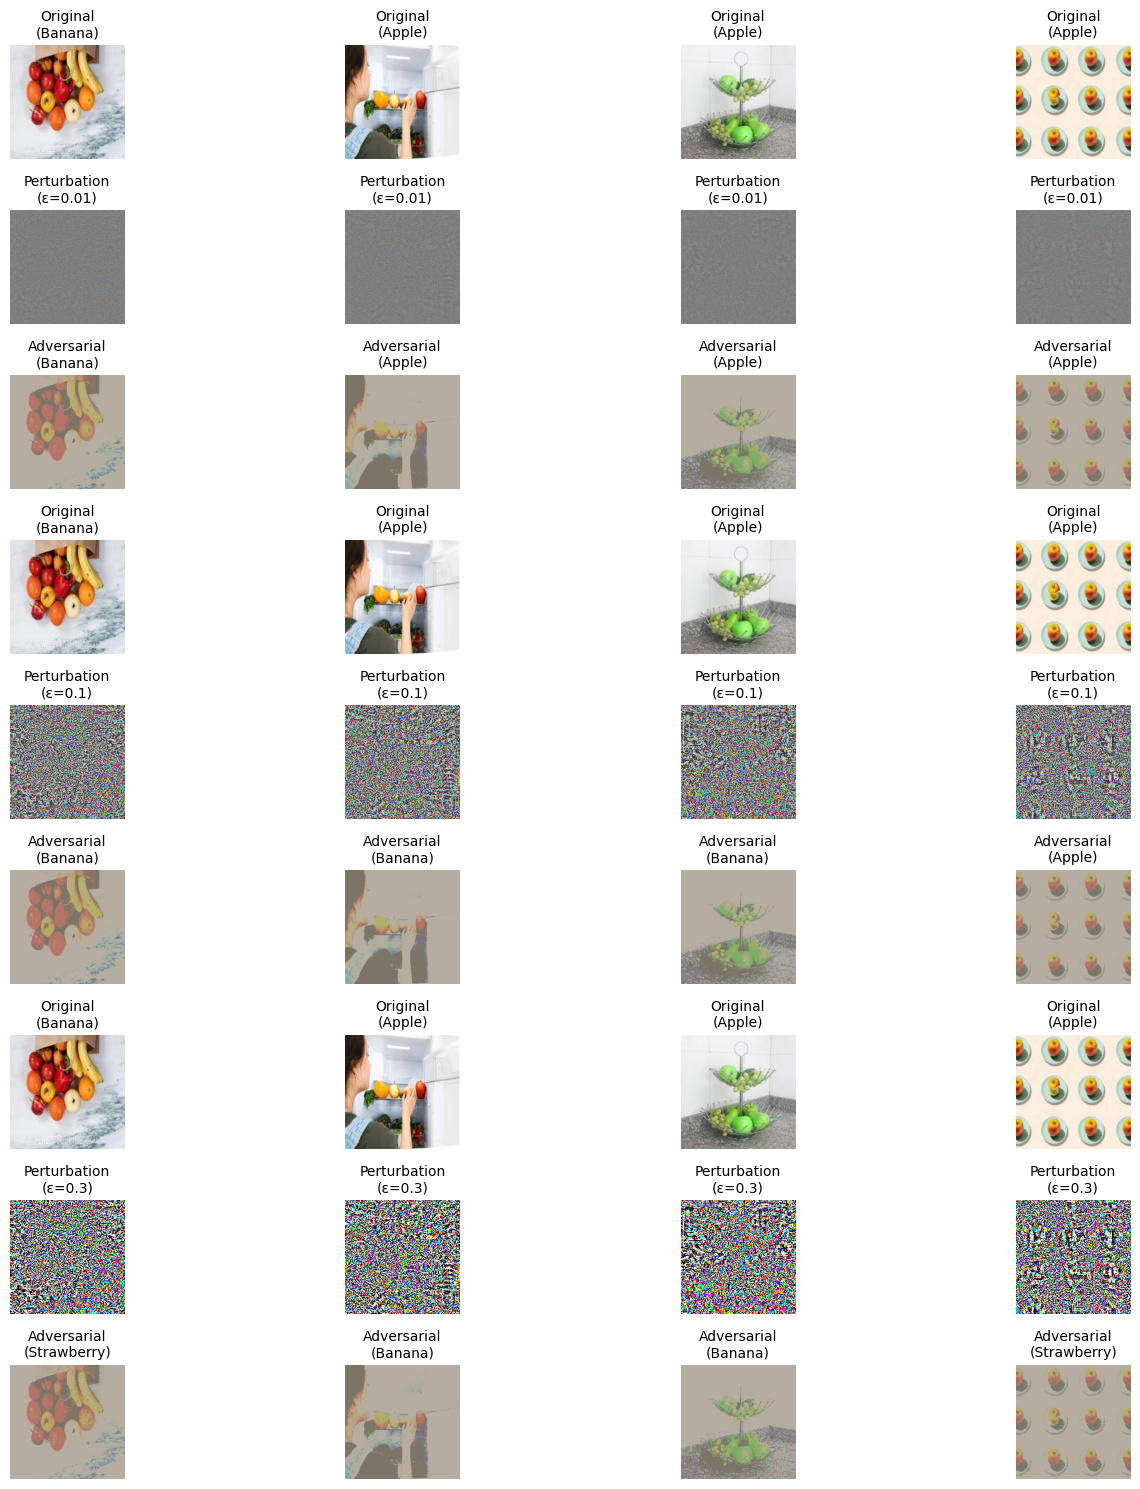

In [5]:
# esempi salvati in examples_store 

fig, axes = plt.subplots(
    len(epsilon_to_visualize) * 3,
    num_images_to_show,
    figsize=(15, 5 * len(epsilon_to_visualize)),
)

axes = axes.reshape(len(epsilon_to_visualize) * 3, num_images_to_show)

for idx_eps, epsilon in enumerate(epsilon_to_visualize):
    if epsilon not in examples_store:
        raise ValueError(f"Esempi per epsilon={epsilon} non trovati. Esegui prima la cella di testing.")

    imgs_cpu = examples_store[epsilon]['images']
    perturbation_batch = examples_store[epsilon]['perturbation']
    adv_images_batch = examples_store[epsilon]['adv_images']
    preds_original_batch = examples_store[epsilon]['preds_original']
    preds_adv_batch = examples_store[epsilon]['preds_adv']

    # riga 1: immagini originali
    row_original = idx_eps * 3

    for img_idx in range(num_images_to_show):
        ax = axes[row_original, img_idx]

        img_original = imgs_cpu[img_idx].numpy()
        img_original = np.transpose(img_original, (1, 2, 0))
        img_original = img_original * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_original = np.clip(img_original, 0, 1)

        ax.imshow(img_original)

        pred_original = int(preds_original_batch[img_idx].item())
        ax.set_title(f"Original\n({class_names[pred_original]})", fontsize=10)
        ax.axis('off')

    # riga 2: perturbazioni
    row_perturbation = idx_eps * 3 + 1

    for img_idx in range(num_images_to_show):
        ax = axes[row_perturbation, img_idx]

        perturbation = perturbation_batch[img_idx].numpy()
        perturbation = np.transpose(perturbation, (1, 2, 0))
        perturbation_amplified = perturbation * 3 + 0.5
        perturbation_amplified = np.clip(perturbation_amplified, 0, 1)

        ax.imshow(perturbation_amplified)
        ax.set_title(f"Perturbation\n(ε={epsilon})", fontsize=10)
        ax.axis('off')

    # riga 3: immagini perturbate
    row_adversarial = idx_eps * 3 + 2

    for img_idx in range(num_images_to_show):
        ax = axes[row_adversarial, img_idx]

        img_adv = adv_images_batch[img_idx].numpy()
        img_adv = np.transpose(img_adv, (1, 2, 0))
        img_adv = img_adv * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_adv = np.clip(img_adv, 0, 1)

        ax.imshow(img_adv)

        pred_adv = int(preds_adv_batch[img_idx].item())
        ax.set_title(f"Adversarial\n({class_names[pred_adv]})", fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig(results_path / "FGSM_adv_perturbations.png", dpi=100, bbox_inches='tight')
plt.show()

## 5. Plot delle Metriche 

Generazioe di grafici riguardanti le metriche:
- Accuracy su immagini originali vs immagini perturbate
- Calo di accuracy (accuracy drop)
- Attack Success Rate (ASR)
- Tempo per applicare l'attacco al test set

/tmp/ipykernel_1905836/3931105937.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
/tmp/ipykernel_1905836/3931105937.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
/tmp/ipykernel_1905836/3931105937.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)


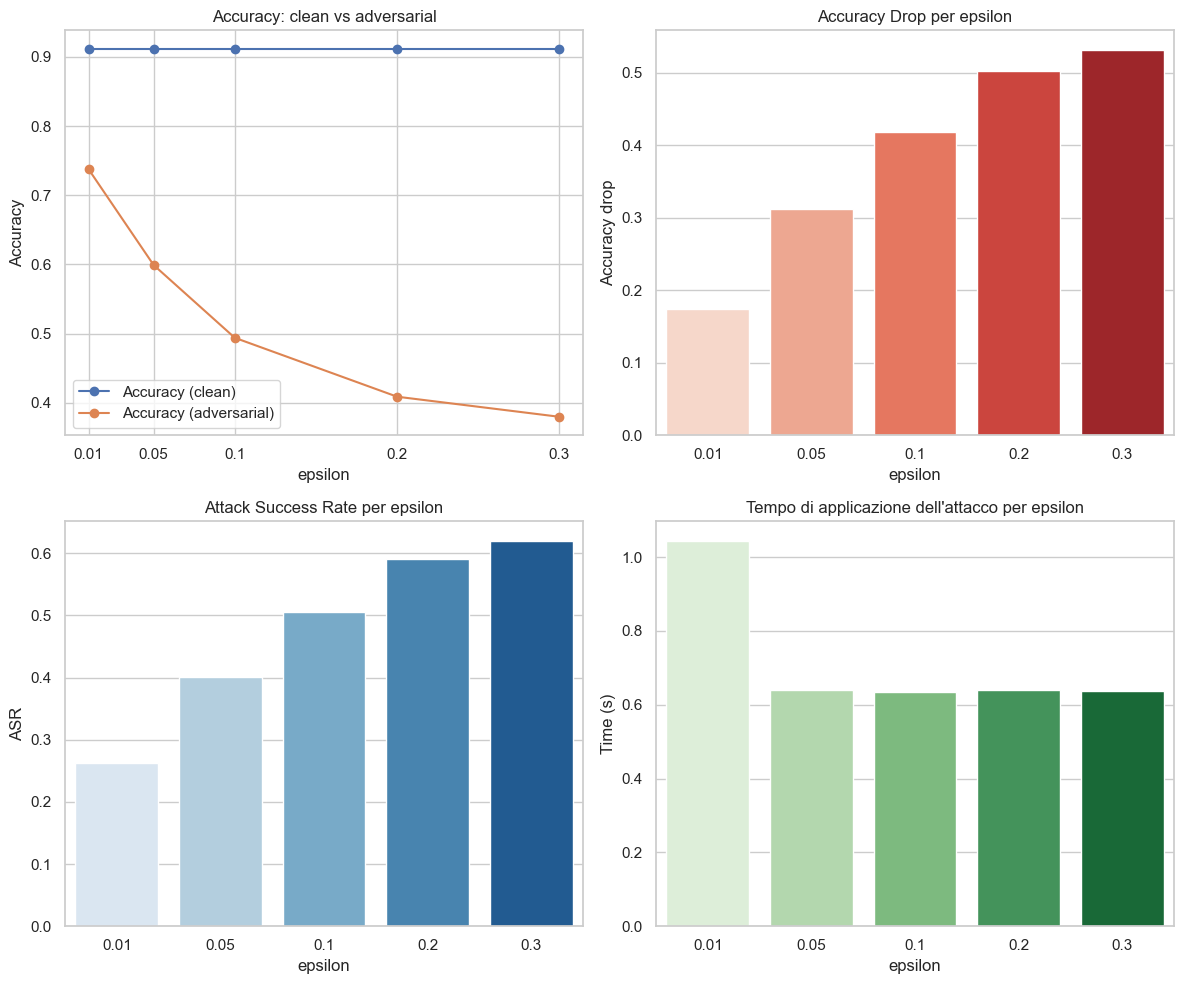

In [6]:
# uso il dizionario fgsm_results calcolato nella fase precedente
eps = epsilon_values
acc = [fgsm_results[e]['accuracy'] for e in eps]
acc_adv = [fgsm_results[e]['accuracy_adv'] for e in eps]
acc_drop = [fgsm_results[e]['accuracy_drop'] for e in eps]
asr = [fgsm_results[e]['asr'] for e in eps]
times = [fgsm_results[e]['time'] for e in eps]

# conversione di epsilon in stringhe per etichette
eps_labels = [str(e) for e in eps]

sns.set(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# accuracy: clean vs adversarial
ax = axes[0, 0]
ax.plot(eps, acc, marker='o', label='Accuracy (clean)')
ax.plot(eps, acc_adv, marker='o', label='Accuracy (adversarial)')
ax.set_xlabel('epsilon')
ax.set_xticks(eps)
ax.set_xticklabels(eps_labels)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: clean vs adversarial')
ax.legend()

# accuracy drop
ax = axes[0, 1]
sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
ax.set_xlabel('epsilon')
ax.set_ylabel('Accuracy drop')
ax.set_title('Accuracy Drop per epsilon')

# Attack Success Rate (ASR)
ax = axes[1, 0]
sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
ax.set_xlabel('epsilon')
ax.set_ylabel('ASR')
ax.set_title('Attack Success Rate per epsilon')

# tempo
ax = axes[1, 1]
sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)
ax.set_xlabel('epsilon')
ax.set_ylabel('Time (s)')
ax.set_title("Tempo di applicazione dell'attacco per epsilon")

plt.tight_layout()
plt.savefig(results_path / 'FGSM_metrics_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# tabella riassuntiva
summary_df = pd.DataFrame({
    'epsilon': eps,
    'accuracy': acc,
    'accuracy_adv': acc_adv,
    'accuracy_drop': acc_drop,
    'asr': asr,
    'time_s': times,
})
summary_df.to_csv(results_path / 'FGSM_metrics_summary.csv', index=False)

## 6. Adversarial Training

Addestramwnto di un nuovo modello con dati misti: 50% immagini originali + 50% immagini perturbate (FGSM con epsilon=0.1).

L'obiettivo è migliorare la robustezza del modello contro attacchi FGSM.

In [7]:
# carica il training set
TRAIN_TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    NORMALIZE
])

train_dataset = ImageFolder(root=dataset_path / 'train', transform=TRAIN_TRANSFORMS)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# nuovo modello (copia di quello originale)
fgsm_model = models.resnet18(pretrained=True)
fgsm_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
fgsm_model = fgsm_model.to(device)

# parametri
epsilon_adv_training = 0.1  # epsilon usato per generare esempi adversarial durante training
adv_optimizer = torch.optim.Adam(fgsm_model.parameters(), lr=0.0001)
adv_loss_fn = nn.CrossEntropyLoss()
patience = 20
best_val_acc = 0
patience_counter = 0
adv_train_history = {'loss': [], 'accuracy': []}

def validate_adv_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    fgsm_model.train()
    epoch_loss = 0
    correct_train = 0
    total_train = 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device)
        
        # generazione esempi adversarial per metà del batch
        batch_size_half = images.size(0) // 2
        clean_images = images[:batch_size_half]
        adv_images_half, _ = fgsm_attack(
            fgsm_model,
            images[batch_size_half:].clone().requires_grad_(True),
            labels[batch_size_half:],
            epsilon_adv_training,
            adv_loss_fn
        )
        
        # clean + adversarial
        mixed_images = torch.cat([clean_images, adv_images_half], dim=0)
        mixed_labels = labels
        
        # Forward pass sul batch misto
        adv_optimizer.zero_grad()
        outputs = fgsm_model(mixed_images)
        loss = adv_loss_fn(outputs, mixed_labels)
        loss.backward()
        adv_optimizer.step()
        
        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == mixed_labels).sum().item()
        total_train += mixed_labels.size(0)
    
    # valutazione su test set
    val_acc = validate_adv_model(fgsm_model, test_loader)
    
    adv_train_history['loss'].append(epoch_loss / len(train_loader))
    adv_train_history['accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1}: Loss={epoch_loss/len(train_loader):.4f}, Val Acc={val_acc:.4f}")
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(fgsm_model.state_dict(), results_path / 'best_fgsm_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# carica il miglior modello
fgsm_model.load_state_dict(torch.load(results_path / 'best_fgsm_model.pt'))
print("Adversarial training completato")
print(f"Miglior val accuracy: {best_val_acc:.4f}")

/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/50: 100%|██████████| 250/250 [00:04<00:00, 55.72it/s]


Epoch 1: Loss=0.7326, Val Acc=0.8978


Epoch 2/50: 100%|██████████| 250/250 [00:04<00:00, 56.81it/s]


Epoch 2: Loss=0.4472, Val Acc=0.9178


Epoch 3/50:  20%|█▉        | 49/250 [00:00<00:03, 56.75it/s]

...

Epoch 22: Loss=0.0459, Val Acc=0.8878


Epoch 23/50: 100%|██████████| 250/250 [00:04<00:00, 56.20it/s]


Epoch 23: Loss=0.0498, Val Acc=0.9108


Epoch 24/50: 100%|██████████| 250/250 [00:04<00:00, 56.17it/s]


Epoch 24: Loss=0.0380, Val Acc=0.9198
Early stopping at epoch 24
Adversarial training completato
Miglior val accuracy: 0.9279


## 7. Confronto: Modello Originale vs Modello FGSM

Confronto del modello originale con il modello addestrato avversarialmente.

Metriche:
- Accuracy su test set pulito
- Accuracy su test set con attacchi FGSM
- Confusion matrix e classification report per entrambi i modelli

MODELLO ORIGINALE:
 Accuracy (clean): 0.9118
 Accuracy (FGSM ε=0.1): 0.4940
 Accuracy drop: 0.4178

MODELLO FGSM (Adversarial Training):
 Accuracy (clean): 0.9279
 Accuracy (FGSM ε=0.1): 0.7615
 Accuracy drop: 0.1663

CONFRONTO:
 Miglioramento accuracy (clean): +1.60%
 Miglioramento accuracy (fgsm): +26.75%


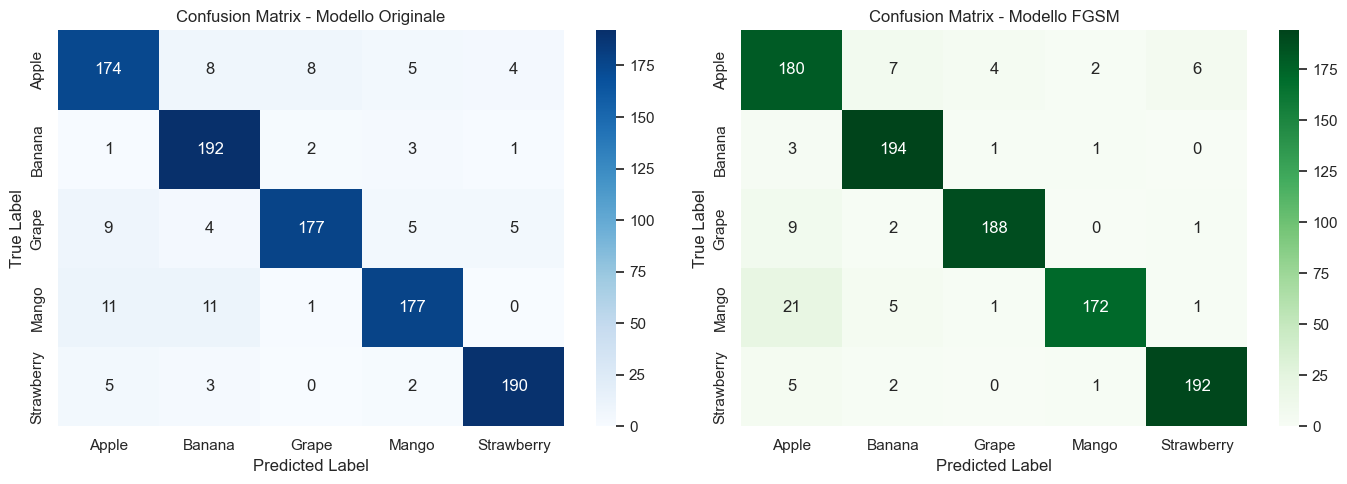


Classification Report - Modello Originale
              precision    recall  f1-score   support

       Apple       0.87      0.87      0.87       199
      Banana       0.88      0.96      0.92       199
       Grape       0.94      0.89      0.91       200
       Mango       0.92      0.89      0.90       200
  Strawberry       0.95      0.95      0.95       200

    accuracy                           0.91       998
   macro avg       0.91      0.91      0.91       998
weighted avg       0.91      0.91      0.91       998


Classification Report - Modello FGSM
              precision    recall  f1-score   support

       Apple       0.83      0.90      0.86       199
      Banana       0.92      0.97      0.95       199
       Grape       0.97      0.94      0.95       200
       Mango       0.98      0.86      0.91       200
  Strawberry       0.96      0.96      0.96       200

    accuracy                           0.93       998
   macro avg       0.93      0.93      0.93       

In [ ]:
epsilon_test = 0.1  # epsilon usato per confronto

def test_model(model, loader, epsilon_val=None):
    model.eval()
    all_preds = []
    all_labels = []
    correct_clean = 0
    correct_adv = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Predizioni su immagini pulite (nessun grad richiesto)
        with torch.no_grad():
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            correct_clean += (preds == labels).sum().item()

        # Genera immagini adversarial se richiesto (richiede grad)
        if epsilon_val is not None:
            adv_images, _ = fgsm_attack(
                model,
                images.clone().requires_grad_(True),
                labels,
                epsilon_val,
                loss_fn
            )

            # Valuta su immagini perturbate (no grad)
            with torch.no_grad():
                outputs_adv = model(adv_images)
                preds_adv = torch.argmax(outputs_adv, dim=1)
                correct_adv += (preds_adv == labels).sum().item()

        total += labels.size(0)

    acc_clean = correct_clean / total
    acc_adv = correct_adv / total if epsilon_val is not None else None

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    return acc_clean, acc_adv, all_preds, all_labels

# Test modello originale
print("MODELLO ORIGINALE:")
acc_orig_clean, acc_orig_adv, preds_orig, labels_orig = test_model(model, test_loader, epsilon_test)
print(f" Accuracy (clean): {acc_orig_clean:.4f}")
print(f" Accuracy (FGSM ε={epsilon_test}): {acc_orig_adv:.4f}")
print(f" Accuracy drop: {acc_orig_clean - acc_orig_adv:.4f}")

# Test modello FGSM
print("\nMODELLO FGSM (Adversarial Training):")
acc_fgsm_clean, acc_fgsm_adv, preds_fgsm, labels_fgsm = test_model(fgsm_model, test_loader, epsilon_test)
print(f" Accuracy (clean): {acc_fgsm_clean:.4f}")
print(f" Accuracy (FGSM ε={epsilon_test}): {acc_fgsm_adv:.4f}")
print(f" Accuracy drop: {acc_fgsm_clean - acc_fgsm_adv:.4f}")

print("\nCONFRONTO:")
print(f" Miglioramento accuracy (clean): {(acc_fgsm_clean - acc_orig_clean)*100:+.2f}%")
print(f" Miglioramento accuracy (fgsm): {(acc_fgsm_adv - acc_orig_adv)*100:+.2f}%")

# matrici di confusione
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_orig = confusion_matrix(labels_orig, preds_orig)
cm_fgsm = confusion_matrix(labels_fgsm, preds_fgsm)

sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Modello Originale')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_fgsm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix - Modello FGSM')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(results_path / 'FGSM_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

# Precision & Recall only (come richiesto)
from sklearn.metrics import precision_recall_fscore_support

prec_orig, rec_orig, _, sup_orig = precision_recall_fscore_support(labels_orig, preds_orig, labels=range(len(class_names)), zero_division=0)
prec_fgsm, rec_fgsm, _, sup_fgsm = precision_recall_fscore_support(labels_fgsm, preds_fgsm, labels=range(len(class_names)), zero_division=0)

df_orig = pd.DataFrame({'class': class_names, 'precision': prec_orig, 'recall': rec_orig, 'support': sup_orig})
df_fgsm = pd.DataFrame({'class': class_names, 'precision': prec_fgsm, 'recall': rec_fgsm, 'support': sup_fgsm})

print("\n" + "=" * 60)
print("Precision & Recall - Modello Originale")
print("=" * 60)
print(df_orig.to_string(index=False))

print("\n" + "=" * 60)
print("Precision & Recall - Modello FGSM")
print("=" * 60)
print(df_fgsm.to_string(index=False))

# Salva risultati in CSV
df_orig.to_csv(results_path / 'classification_precision_recall_original.csv', index=False)
df_fgsm.to_csv(results_path / 'classification_precision_recall_fgsm.csv', index=False)

In [ ]:
# -----------------------------
# Optional: Confidence Drop & Saliency Heatmaps
# -----------------------------
import torch.nn.functional as F

def compute_confidence_drop(model, loader, epsilon, n_examples=100):
    model.eval()
    drops = []
    count = 0
    for images, labels in loader:
        for i in range(images.size(0)):
            img = images[i:i+1].to(device)
            lbl = labels[i].to(device)

            with torch.no_grad():
                out = model(img)
                prob = F.softmax(out, dim=1)[0, lbl].item()

            # generate adversarial example (requires grad)
            adv_img, _ = fgsm_attack(model, img.clone().requires_grad_(True), lbl.unsqueeze(0), epsilon, loss_fn)

            with torch.no_grad():
                out_adv = model(adv_img)
                prob_adv = F.softmax(out_adv, dim=1)[0, lbl].item()

            drops.append(prob - prob_adv)
            count += 1
            if count >= n_examples:
                break
        if count >= n_examples:
            break
    return np.array(drops)

# calcola confidence drop per entrambi i modelli
print('Calcolo confidence drop...')
drops_orig = compute_confidence_drop(model, test_loader, epsilon_test, n_examples=200)
drops_fgsm = compute_confidence_drop(fgsm_model, test_loader, epsilon_test, n_examples=200)

print(f"Mean confidence drop (original): {drops_orig.mean():.4f}")
print(f"Mean confidence drop (fgsm): {drops_fgsm.mean():.4f}")

pd.DataFrame({'confidence_drop': drops_orig}).to_csv(results_path / 'confidence_drop_original.csv', index=False)
pd.DataFrame({'confidence_drop': drops_fgsm}).to_csv(results_path / 'confidence_drop_fgsm.csv', index=False)

# Saliency maps (simple gradient-based saliency)
from matplotlib.cm import jet

def compute_saliency(model, img, label):
    model.eval()
    img = img.clone().to(device).requires_grad_(True)
    out = model(img)
    score = out[0, label]
    model.zero_grad()
    score.backward()
    sal = img.grad.abs().mean(dim=1).squeeze().cpu().numpy()  # HxW
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
    return sal

# seleziona alcune immagini correttamente classificate
num_show = 4
selected = []
for images, labels in test_loader:
    for i in range(images.size(0)):
        if len(selected) >= num_show:
            break
        img = images[i:i+1]
        lbl = labels[i].item()
        with torch.no_grad():
            out = model(img.to(device))
            pred = torch.argmax(out, dim=1).item()
        if pred == lbl:
            selected.append((img, lbl))
    if len(selected) >= num_show:
        break

fig, axes = plt.subplots(num_show, 4, figsize=(16, 4 * num_show))
for idx, (img, lbl) in enumerate(selected):
    # clean image
    img_cpu = img[0].numpy()
    img_vis = np.transpose(img_cpu, (1,2,0)) * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    img_vis = np.clip(img_vis, 0, 1)

    # saliency before attack
    sal_before = compute_saliency(model, img, lbl)

    # adversarial image (wrt original model)
    adv_img, _ = fgsm_attack(model, img.clone().requires_grad_(True).to(device), torch.tensor([lbl]).to(device), epsilon_test, loss_fn)
    adv_cpu = adv_img[0].detach().cpu().numpy()
    adv_vis = np.transpose(adv_cpu, (1,2,0)) * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    adv_vis = np.clip(adv_vis, 0, 1)

    # saliency after attack
    sal_after = compute_saliency(model, adv_img.detach(), lbl)

    # plot original
    ax = axes[idx, 0]
    ax.imshow(img_vis)
    ax.set_title(f'Original (label={class_names[lbl]})')
    ax.axis('off')

    # plot saliency before (overlay)
    ax = axes[idx, 1]
    ax.imshow(img_vis)
    ax.imshow(sal_before, cmap='jet', alpha=0.5)
    ax.set_title('Saliency before')
    ax.axis('off')

    # plot adversarial
    ax = axes[idx, 2]
    ax.imshow(adv_vis)
    ax.set_title('Adversarial')
    ax.axis('off')

    # plot saliency after
    ax = axes[idx, 3]
    ax.imshow(adv_vis)
    ax.imshow(sal_after, cmap='jet', alpha=0.5)
    ax.set_title('Saliency after')
    ax.axis('off')

plt.tight_layout()
plt.savefig(results_path / 'saliency_before_after.png', dpi=120, bbox_inches='tight')
plt.show()

**Conclusioni: FGSM attack e Adversarial Training (Sintesi)**

- **Cosa abbiamo fatto:** valutazione FGSM su più epsilon, visualizzazioni (perturbazioni + immagini adversarial), adversarial training con FGSM (50% clean + 50% adv), confronto tra `model` e `fgsm_model`.
- **Metriche principali salvate:** `results/FGSM_metrics_summary.csv`, `results/FGSM_metrics_summary.png` (accuracy, accuracy drop, ASR, tempo).
- **Confronto tra modelli:** confusion matrices e precision/recall salvati in `results/FGSM_confusion_matrices.png`, `results/classification_precision_recall_original.csv`, `results/classification_precision_recall_fgsm.csv`.
- **Analisi aggiuntive:** `confidence_drop` per entrambi i modelli salvato come CSV e `saliency_before_after.png` con heatmap di saliency prima/dopo attacco.
- **Osservazioni generali:** l'attacco FGSM riduce l'accuracy del modello originale; l'adversarial training con FGSM tende a ridurre l'accuracy drop (migliora la robustezza) ma può comportare un leggero calo di accuracy su immagini pulite — verificare trade-off sui risultati salvati.
- **Prossimi passi consigliati:** misurare il "generalization gap" addestrando un modello con un attacco diverso (es. PGD) e valutandolo con FGSM; estendere saliency heatmap anche a `fgsm_model` per un confronto diretto.

Se vuoi, eseguo subito il confronto saliency anche su `fgsm_model` e aggiungo l'analisi del generalization gap (richiede addestramento PGD).